# Sinusoid Regression: Kron Last Layer (Laplace) vs Bayesian-Torch BNNs

Head-to-head comparison on a larger sinusoid dataset (600 / 200 / 200 / 200 train-val-testID-testOOD).
Laplace side: `kron / last_layer` with `marglik` and `gridsearch` tuning.
BNN side: Flipout and BBB (Reparameterization) × scratch and MOPED initialization.

In [66]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, regression_uncertainty_stats,
                    load_sinusoid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 711
sigma_noise = 0.3
num_mc_samples = 100
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_comparison_1seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"Checkpoint dir: {CHECKPOINT_BASE}")

Device: cuda
Checkpoint dir: /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_comparison_1seed


In [67]:
# Dataset: 1000 pts total — 60/20/20 ID split + equal-size OOD test
data = load_sinusoid(
    n_data=600, sigma_noise=sigma_noise, batch_size=64, seed=SEED, device=device,
    n_val=200, n_test_id=200, n_test_ood=200,
)
X_train, y_train = data["X_train"], data["y_train"]
train_loader     = data["train_loader"]
X_val, y_val     = data["X_val"], data["y_val"]
val_loader       = data["val_loader"]
X_test_id,  y_test_id  = data["X_test_id"],  data["y_test_id"]
X_test_ood, y_test_ood = data["X_test_ood"], data["y_test_ood"]
X_train_np    = X_train.flatten().numpy()
y_train_np    = y_train.flatten().numpy()
y_val_np      = y_val.flatten().numpy()
y_test_id_np  = y_test_id.flatten().numpy()
y_test_ood_np = y_test_ood.flatten().numpy()
X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)
x_grid = X_test_grid.flatten().numpy()

print(f"Train: {len(X_train)}, Val: {len(X_val)}, "
      f"Test ID: {len(X_test_id)}, Test OOD: {len(X_test_ood)}")

Train: 600, Val: 200, Test ID: 200, Test OOD: 200


In [68]:
def get_model():
    seed_everything(SEED)
    return nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50, 1))

def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax):
    epi = np.asarray(epistemic_std).ravel()
    total = np.sqrt(epi**2 + float(aleatoric_std)**2)
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.25, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Mean")
    ax.fill_between(x_grid, f_mu-2*total, f_mu+2*total,
                    color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu-2*epi, f_mu+2*epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)

# MAP (shared between Laplace and BNN)
map_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{SEED}.pt")
map_model = get_model()
criterion = nn.MSELoss()
if checkpoint_exists(map_ckpt):
    map_model.load_state_dict(load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
    print("Loaded MAP checkpoint")
else:
    opt = optim.Adam(map_model.parameters(), lr=1e-2)
    t0 = time.time()
    for epoch in range(2000):
        for xb, yb in train_loader:
            opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
    fit_time = time.time() - t0
    save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": fit_time}, map_ckpt)
    print(f"Trained MAP ({fit_time:.1f}s)")
map_model.eval()
with torch.no_grad():
    map_resid_std = float((y_train - map_model(X_train)).std().item())
print(f"MAP params: {sum(p.numel() for p in map_model.parameters()):,}, "
      f"resid_std={map_resid_std:.4f}")

Loaded MAP checkpoint
MAP params: 151, resid_std=0.2937


In [69]:
def la_predict(la_model, X):
    f_mu, f_var = la_model(X)
    return f_mu.squeeze().detach().cpu().numpy(), f_var.squeeze().sqrt().detach().cpu().numpy()

la_variant_specs = [
    {"variant_name": "kron_last_layer_marglik",    "tune": "marglik",
     "plot_title": "Kron / last layer / marglik"},
    {"variant_name": "kron_last_layer_gridsearch", "tune": "gridsearch",
     "plot_title": "Kron / last layer / gridsearch"},
    {"variant_name": "kron_last_layer_adam_loop",  "tune": "adam_loop",
     "plot_title": "Kron / last layer / adam loop"},
]

la_results = {}

for spec in la_variant_specs:
    vname = spec["variant_name"]
    la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{SEED}.pt")

    base = get_model()
    base.load_state_dict(map_model.state_dict())
    la = Laplace(base, "regression", subset_of_weights="last_layer", hessian_structure="kron")

    loaded = False
    if checkpoint_exists(la_ckpt):
        payload = load_checkpoint(la_ckpt)
        if isinstance(payload, dict) and payload.get("la") is not None:
            la = payload["la"]; metrics = payload.get("metrics", {}); loaded = True
        elif isinstance(payload, dict) and payload.get("la_state_dict") is not None:
            try:
                la.fit(train_loader)
                la.load_state_dict(payload["la_state_dict"])
            except (AttributeError, TypeError):
                la.fit(train_loader)
                la.load_state_dict(payload["la_state_dict"])
            metrics = payload.get("metrics", {}); loaded = True

    if not loaded:
        t0 = time.time(); la.fit(train_loader)
        metrics = {"Tune_Method": spec["tune"], "Fit_Time (s)": time.time()-t0}
        t1 = time.time()
        if spec["tune"] == "adam_loop":
            log_prior = torch.ones(1, requires_grad=True)
            log_sigma = torch.ones(1, requires_grad=True)
            hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
            for _ in range(1000):
                hyp_opt.zero_grad()
                (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                hyp_opt.step()
            la.prior_precision = log_prior.exp().detach()
            la.sigma_noise = log_sigma.exp().detach()
        else:
            la.sigma_noise = torch.tensor(map_resid_std)
            if spec["tune"] == "marglik":
                la.optimize_prior_precision(method="marglik")
            else:
                la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
        metrics["Tune_Time (s)"] = time.time()-t1
        metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
        metrics["Sigma_Noise"] = float(la.sigma_noise.item())
        save_checkpoint({"la": la, "la_state_dict": la.state_dict(), "metrics": metrics}, la_ckpt)

    sigma = float(la.sigma_noise.item())
    metrics["Sigma_Noise"] = sigma
    f_mu, epi_std = la_predict(la, X_test_grid)
    mu_id, epi_id = la_predict(la, X_test_id)
    mu_ood, epi_ood = la_predict(la, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    la_results[vname] = {
        "la": la, "f_mu": f_mu, "epi_std": epi_std, "sigma": sigma,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    status = "loaded" if loaded else "fitted"
    print(f"  [{status}] {vname}: RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}")

  [loaded] kron_last_layer_marglik: RMSE=0.2990  NLL=0.2121
  [loaded] kron_last_layer_gridsearch: RMSE=0.2990  NLL=0.2119
  [loaded] kron_last_layer_adam_loop: RMSE=0.2990  NLL=0.2121


## Laplace — all weights variants

Extending the Laplace comparison to `subset_of_weights="all"` with two Hessian structures:
- **Kron / all weights**: Kronecker-factored Hessian over all layers (same three tuning methods as last-layer)
- **Full / all weights / gridsearch**: Full Hessian over all weights — feasible here because the network is tiny (151 params)

In [70]:
la_allweights_specs = [
    {"variant_name": "kron_all_marglik",    "subset": "all", "hessian": "kron",
     "tune": "marglik",    "plot_title": "Kron / all weights / marglik"},
    {"variant_name": "kron_all_gridsearch", "subset": "all", "hessian": "kron",
     "tune": "gridsearch", "plot_title": "Kron / all weights / gridsearch"},
    {"variant_name": "kron_all_adam_loop",  "subset": "all", "hessian": "kron",
     "tune": "adam_loop",  "plot_title": "Kron / all weights / adam loop"},
    {"variant_name": "full_all_gridsearch", "subset": "all", "hessian": "full",
     "tune": "gridsearch", "plot_title": "Full / all weights / gridsearch"},
]

for spec in la_allweights_specs:
    vname = spec["variant_name"]
    la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_la_{vname}_seed{SEED}.pt")

    base = get_model()
    base.load_state_dict(map_model.state_dict())
    la = Laplace(base, "regression",
                 subset_of_weights=spec["subset"],
                 hessian_structure=spec["hessian"])

    loaded = False
    if checkpoint_exists(la_ckpt):
        payload = load_checkpoint(la_ckpt)
        if isinstance(payload, dict) and payload.get("la") is not None:
            la = payload["la"]; metrics = payload.get("metrics", {}); loaded = True
        elif isinstance(payload, dict) and payload.get("la_state_dict") is not None:
            try:
                la.fit(train_loader)
                la.load_state_dict(payload["la_state_dict"])
            except Exception:
                pass
            metrics = payload.get("metrics", {}); loaded = True

    if not loaded:
        t0 = time.time(); la.fit(train_loader)
        metrics = {"Tune_Method": spec["tune"], "Fit_Time (s)": time.time() - t0}
        t1 = time.time()
        if spec["tune"] == "adam_loop":
            log_prior = torch.ones(1, requires_grad=True)
            log_sigma = torch.ones(1, requires_grad=True)
            hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
            for _ in range(1000):
                hyp_opt.zero_grad()
                (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                hyp_opt.step()
            la.prior_precision = log_prior.exp().detach()
            la.sigma_noise = log_sigma.exp().detach()
        else:
            la.sigma_noise = torch.tensor(map_resid_std)
            if spec["tune"] == "marglik":
                la.optimize_prior_precision(method="marglik")
            else:
                la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
        metrics["Tune_Time (s)"] = time.time() - t1
        metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
        metrics["Sigma_Noise"] = float(la.sigma_noise.item())
        save_checkpoint({"la": la, "la_state_dict": la.state_dict(), "metrics": metrics}, la_ckpt)

    sigma = float(la.sigma_noise.item())
    metrics["Sigma_Noise"] = sigma
    f_mu, epi_std = la_predict(la, X_test_grid)
    mu_id, epi_id = la_predict(la, X_test_id)
    mu_ood, epi_ood = la_predict(la, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    result = {
        "la": la, "f_mu": f_mu, "epi_std": epi_std, "sigma": sigma,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    status = "loaded" if loaded else "fitted"
    print(f"  [{status}] {vname}: RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}")

    # append to shared dicts so downstream cells pick them up
    la_results[vname] = result
    la_variant_specs.append(spec)

  [loaded] kron_all_marglik: RMSE=0.2990  NLL=0.2131
  [loaded] kron_all_gridsearch: RMSE=0.2990  NLL=0.2120
  [loaded] kron_all_adam_loop: RMSE=0.2990  NLL=0.2131
  [loaded] full_all_gridsearch: RMSE=0.2990  NLL=0.2119


In [71]:
def build_bnn(model_type, moped, moped_delta=0.5):
    net = get_model()
    if moped:
        net.load_state_dict(map_model.state_dict())
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": moped_delta,
    })
    return net

def bnn_predict(net, X, n_samples=num_mc_samples):
    net.eval()
    with torch.no_grad():
        preds = torch.stack([net(X) for _ in range(n_samples)])
    return preds.mean(0).squeeze().cpu().numpy(), preds.std(0).squeeze().cpu().numpy()

bnn_variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        bnn_variant_specs.append({
            "variant_name": f"{short}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,
            "plot_title": f"{short.upper() if short == 'bbb' else short.capitalize()} / {init}",
        })

bnn_results = {}

for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{SEED}.pt")
    net = build_bnn(spec["model_type"], spec["moped"])

    if checkpoint_exists(ckpt):
        payload = load_checkpoint(ckpt, map_location="cpu")
        if isinstance(payload, dict) and "model_state_dict" in payload:
            net.load_state_dict(payload["model_state_dict"])
            metrics = dict(payload.get("metrics", {}))
            print(f"  [loaded] {vname}")
    else:
        opt_b = optim.Adam(net.parameters(), lr=1e-3)
        num_samp = len(X_train)
        patience = 75; best_val, best_state, wait, ran = float("inf"), None, 0, 0
        t0 = time.time()
        for epoch in range(spec["epochs"]):
            net.train()
            for xb, yb in train_loader:
                opt_b.zero_grad()
                loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samp
                loss.backward(); opt_b.step()
            ran = epoch + 1
            f_mu_val, _ = bnn_predict(net, X_val, n_samples=20)
            val_mse = float(np.mean((f_mu_val - y_val_np)**2))
            if val_mse < best_val - 1e-5:
                best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
            else:
                wait += 1
                if wait >= patience: break
        if best_state is not None:
            net.load_state_dict(best_state)
        fit_time = time.time() - t0
        metrics = {
            "Model_Type": spec["model_type"], "Init": "MOPED" if spec["moped"] else "scratch",
            "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time,
        }
        save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
        print(f"  [trained] {vname} ({fit_time:.1f}s, {ran} epochs)")

    f_mu, epi_std = bnn_predict(net, X_test_grid)
    mu_id, epi_id = bnn_predict(net, X_test_id)
    mu_ood, epi_ood = bnn_predict(net, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma_noise**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma_noise))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    bnn_results[vname] = {
        "model": net, "f_mu": f_mu, "epi_std": epi_std,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    print(f"    RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}")

  [loaded] flipout_scratch
    RMSE=0.3101  NLL=0.2580
  [loaded] flipout_moped
    RMSE=0.3500  NLL=0.4182
  [loaded] bbb_scratch
    RMSE=0.3083  NLL=0.2505
  [loaded] bbb_moped
    RMSE=0.6277  NLL=1.2282


In [72]:
# Combined metrics table
rows = []
labels = []
for spec in la_variant_specs:
    vname = spec["variant_name"]
    m = dict(la_results[vname]["metrics"])
    m["Method"] = "Laplace"
    rows.append(m); labels.append(spec["plot_title"])
for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    m = dict(bnn_results[vname]["metrics"])
    m["Method"] = "BNN"
    rows.append(m); labels.append(spec["plot_title"])

eval_df = pd.DataFrame(rows, index=labels)
eval_df.index.name = "Variant"

preferred_cols = [
    "Method", "RMSE", "MAE", "NLL",
    "Calibration_MAE", "Calibration_MSE", "Coverage_68", "Coverage_95",
    "Mean_Epistemic_Std", "Mean_Total_Std",
]
existing = [c for c in preferred_cols if c in eval_df.columns]
disp = eval_df[existing].copy()
for c in disp.columns:
    if pd.api.types.is_float_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
print("Sinusoid Comparison — ID Test Metrics")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
eval_df.to_csv("results/metrics/sinusoid_comparison_metrics.csv")
print("\nSaved to results/metrics/sinusoid_comparison_metrics.csv")

Sinusoid Comparison — ID Test Metrics


,Method,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Coverage_68,Coverage_95,Mean_Epistemic_Std,Mean_Total_Std
Variant,,,,,,,,,,
Kron / last layer / marglik,Laplace,0.2990,0.2382,0.2121,0.0146,0.0003,0.6600,0.9400,0.0338,0.2958
Kron / last layer / gridsearch,Laplace,0.2990,0.2382,0.2119,0.0146,0.0003,0.6600,0.9350,0.0183,0.2943
Kron / last layer / adam loop,Laplace,0.2990,0.2382,0.2121,0.0143,0.0003,0.6600,0.9400,0.0338,0.2960
Kron / all weights / marglik,Laplace,0.2990,0.2382,0.2131,0.0125,0.0003,0.6600,0.9500,0.0577,0.2996
Kron / all weights / gridsearch,Laplace,0.2990,0.2382,0.2120,0.0139,0.0003,0.6600,0.9400,0.0258,0.2949
Kron / all weights / adam loop,Laplace,0.2990,0.2382,0.2131,0.0127,0.0003,0.6600,0.9500,0.0577,0.2998
Full / all weights / gridsearch,Laplace,0.2990,0.2382,0.2119,0.0144,0.0003,0.6600,0.9350,0.0200,0.2944
Flipout / scratch,BNN,0.3101,0.2505,0.2580,0.0187,0.0006,0.7400,0.9650,0.1373,0.3316
Flipout / moped,BNN,0.3500,0.2770,0.4182,0.0745,0.0066,0.7800,0.9850,0.3159,0.4371



Saved to results/metrics/sinusoid_comparison_metrics.csv


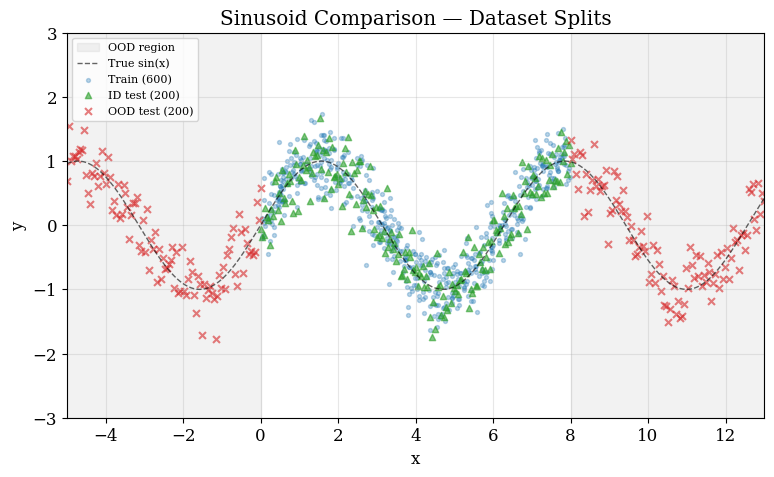

In [73]:
# Dataset visualization: train + ID test + OOD test
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.3, label="Train (600)")
ax.scatter(X_test_id.flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=20,
           alpha=0.6, label="ID test (200)")
ax.scatter(X_test_ood.flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=25,
           alpha=0.6, label="OOD test (200)")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Sinusoid Comparison — Dataset Splits")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_comparison_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

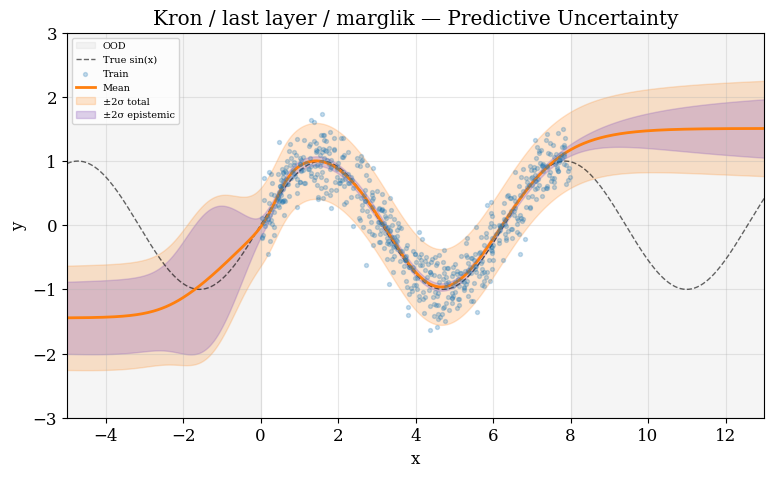

  Saved: sinusoid_comparison_kron_last_layer_marglik_prediction.png


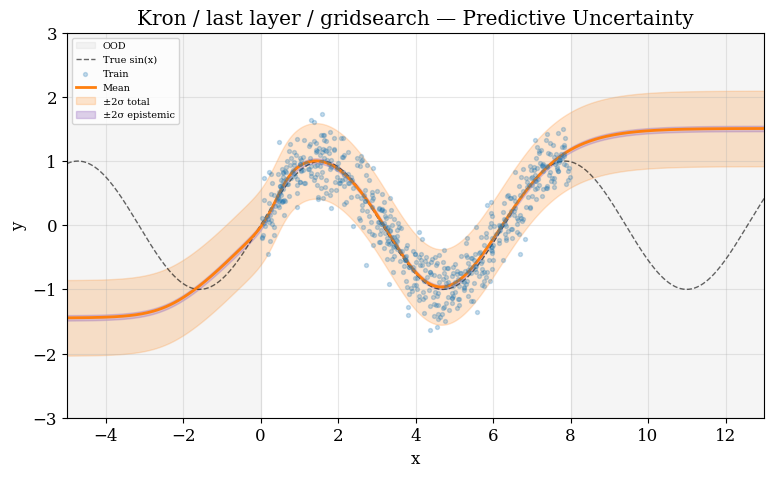

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_prediction.png


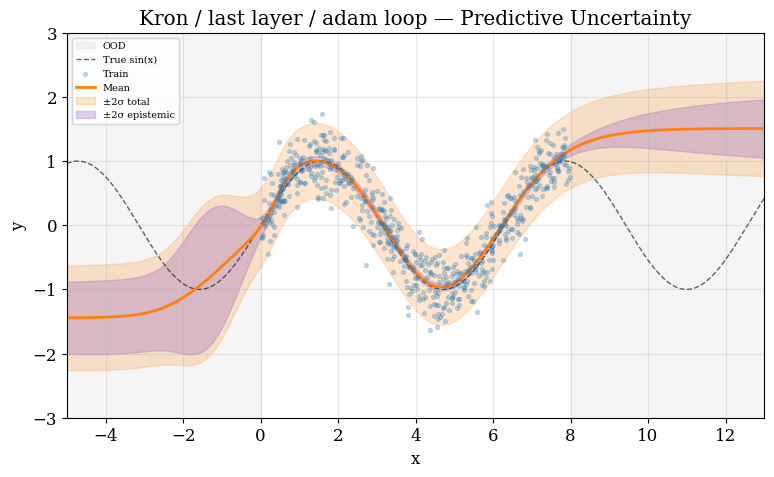

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_prediction.png


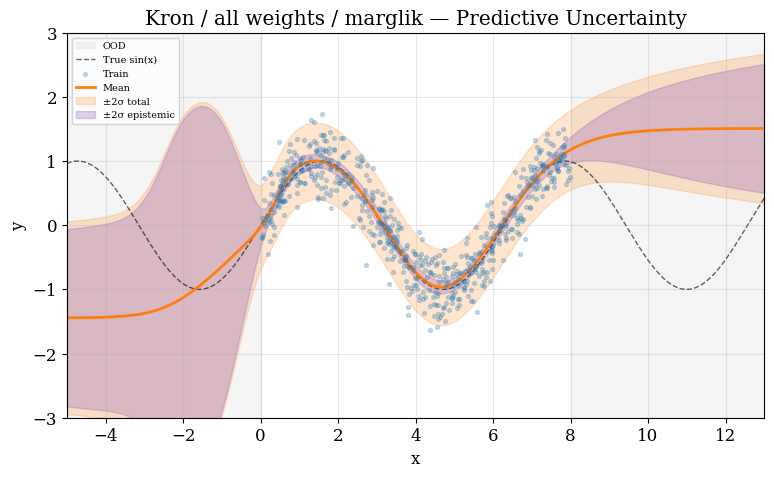

  Saved: sinusoid_comparison_kron_all_marglik_prediction.png


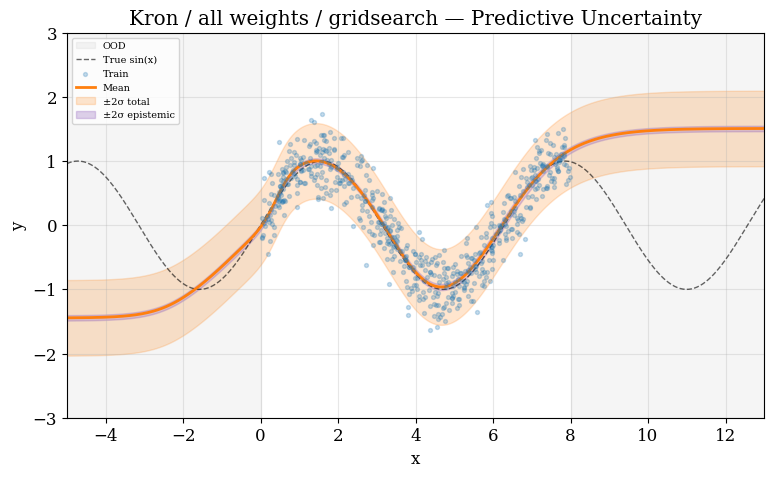

  Saved: sinusoid_comparison_kron_all_gridsearch_prediction.png


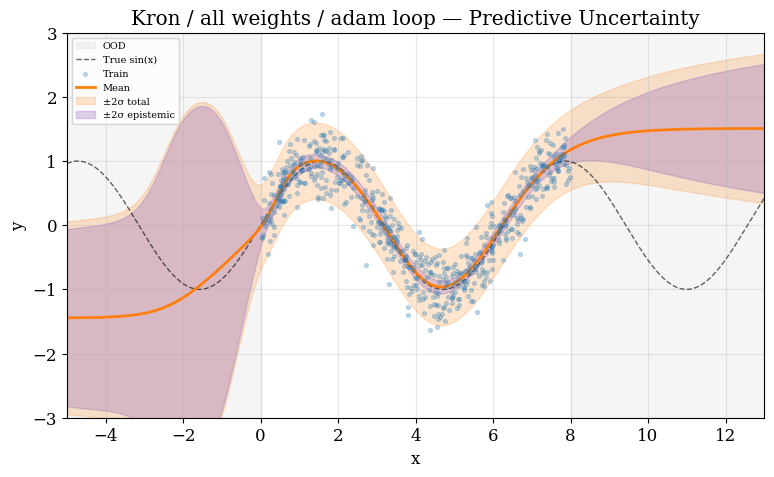

  Saved: sinusoid_comparison_kron_all_adam_loop_prediction.png


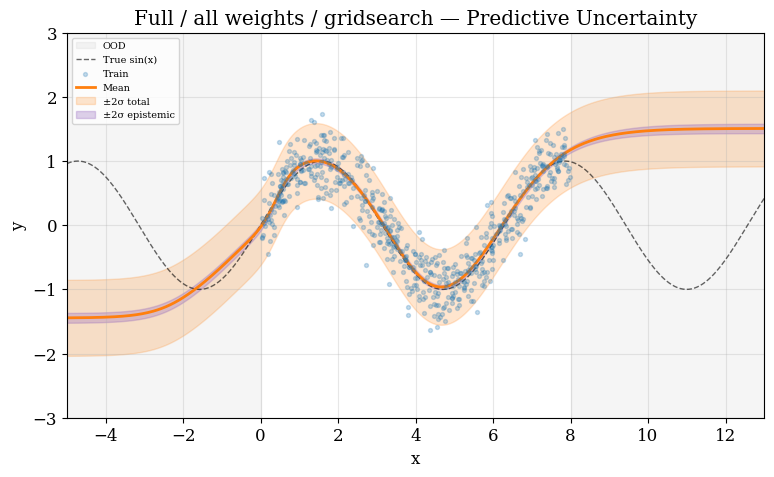

  Saved: sinusoid_comparison_full_all_gridsearch_prediction.png


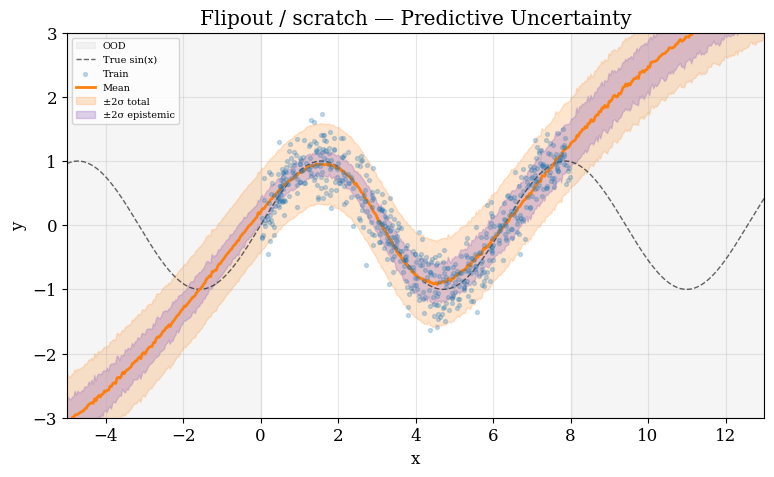

  Saved: sinusoid_comparison_flipout_scratch_prediction.png


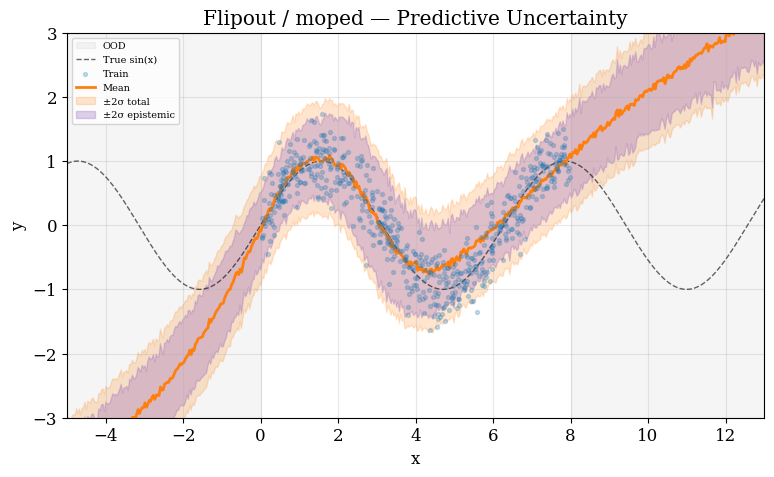

  Saved: sinusoid_comparison_flipout_moped_prediction.png


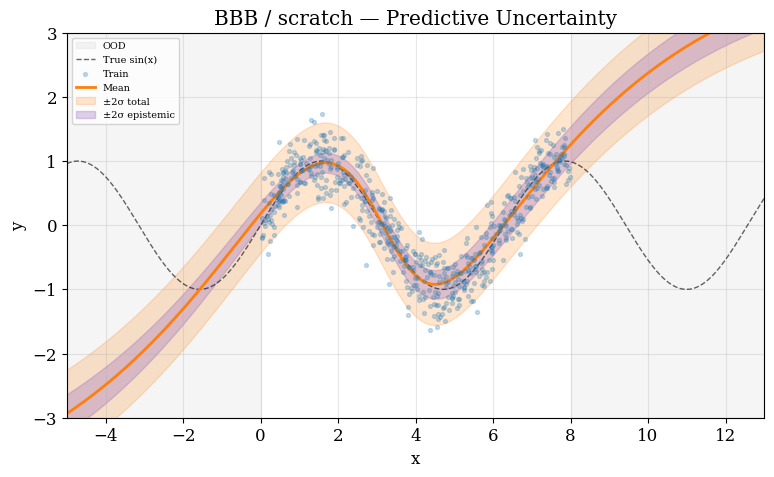

  Saved: sinusoid_comparison_bbb_scratch_prediction.png


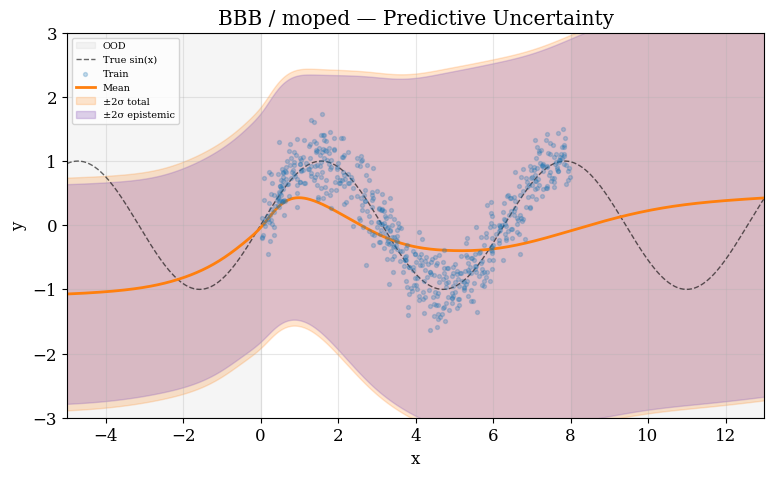

  Saved: sinusoid_comparison_bbb_moped_prediction.png


In [74]:
# Per-variant prediction figures
all_specs_and_results = (
    [(s, la_results[s["variant_name"]], "Laplace") for s in la_variant_specs] +
    [(s, bnn_results[s["variant_name"]], "BNN") for s in bnn_variant_specs]
)
for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    sigma = res.get("sigma", sigma_noise)
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma,
                    f"{title} — Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_prediction.png")

In [75]:
# ID vs OOD scored metrics
ood_rows = []
ood_labels = []

for spec in la_variant_specs:
    vname = spec["variant_name"]
    res = la_results[vname]; sigma = res["sigma"]
    m_id  = regression_metrics(y_test_id_np,  res["mu_id"],  np.sqrt(res["epi_id"]**2  + sigma**2))
    m_ood = regression_metrics(y_test_ood_np, res["mu_ood"], np.sqrt(res["epi_ood"]**2 + sigma**2))
    ood_rows.append({
        "Method": "Laplace",
        "ID NLL": m_id["NLL"],   "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"], "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic":  float(res["epi_id"].mean()),
        "OOD Epistemic": float(res["epi_ood"].mean()),
        "Epistemic Ratio (OOD/ID)": float(res["epi_ood"].mean() / (res["epi_id"].mean() + 1e-12)),
    })
    ood_labels.append(spec["plot_title"])

for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    res = bnn_results[vname]
    m_id  = regression_metrics(y_test_id_np,  res["mu_id"],  np.sqrt(res["epi_id"]**2  + sigma_noise**2))
    m_ood = regression_metrics(y_test_ood_np, res["mu_ood"], np.sqrt(res["epi_ood"]**2 + sigma_noise**2))
    ood_rows.append({
        "Method": "BNN",
        "ID NLL": m_id["NLL"],   "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"], "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic":  float(res["epi_id"].mean()),
        "OOD Epistemic": float(res["epi_ood"].mean()),
        "Epistemic Ratio (OOD/ID)": float(res["epi_ood"].mean() / (res["epi_id"].mean() + 1e-12)),
    })
    ood_labels.append(spec["plot_title"])

ood_df = pd.DataFrame(ood_rows, index=ood_labels)
ood_df.index.name = "Variant"
print("ID vs OOD — higher OOD NLL/RMSE and epistemic ratio > 1 indicates good uncertainty awareness")
display(ood_df.round(4))

ood_df.to_csv("results/metrics/sinusoid_comparison_ood_metrics.csv")
print("\nSaved to results/metrics/sinusoid_comparison_ood_metrics.csv")

ID vs OOD — higher OOD NLL/RMSE and epistemic ratio > 1 indicates good uncertainty awareness


,Method,ID NLL,OOD NLL,ID RMSE,OOD RMSE,ID Coverage_95,OOD Coverage_95,ID Epistemic,OOD Epistemic,Epistemic Ratio (OOD/ID)
Variant,,,,,,,,,,
Kron / last layer / marglik,Laplace,0.2121,9.9704,0.2990,1.6180,0.940,0.315,0.0338,0.2431,7.1879
Kron / last layer / gridsearch,Laplace,0.2119,14.7911,0.2990,1.6180,0.935,0.260,0.0183,0.0213,1.1642
Kron / last layer / adam loop,Laplace,0.2121,9.9640,0.2990,1.6180,0.940,0.315,0.0338,0.2429,7.1782
Kron / all weights / marglik,Laplace,0.2131,5.0232,0.2990,1.6180,0.950,0.425,0.0577,0.6227,10.7995
Kron / all weights / gridsearch,Laplace,0.2120,14.7898,0.2990,1.6180,0.940,0.260,0.0258,0.0217,0.8430
Kron / all weights / adam loop,Laplace,0.2131,5.0182,0.2990,1.6180,0.950,0.425,0.0577,0.6229,10.7961
Full / all weights / gridsearch,Laplace,0.2119,14.6453,0.2990,1.6180,0.935,0.260,0.0200,0.0342,1.7062
Flipout / scratch,BNN,0.2580,28.1407,0.3101,2.6562,0.965,0.230,0.1373,0.1662,1.2106
Flipout / moped,BNN,0.4182,19.3282,0.3500,2.7473,0.985,0.240,0.3159,0.3233,1.0232



Saved to results/metrics/sinusoid_comparison_ood_metrics.csv


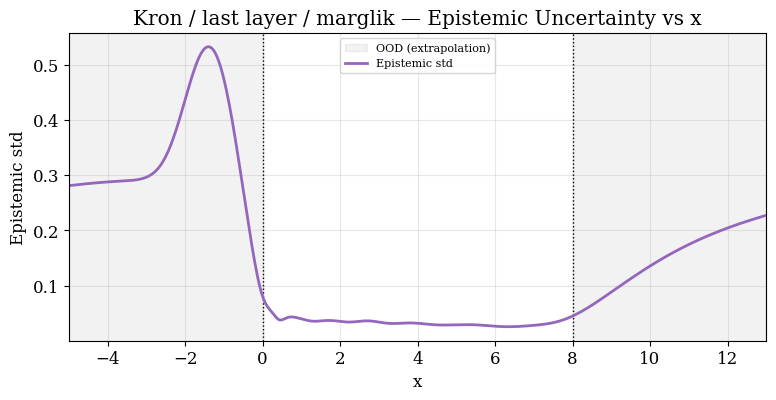

  Saved: sinusoid_comparison_kron_last_layer_marglik_ood_epistemic.png


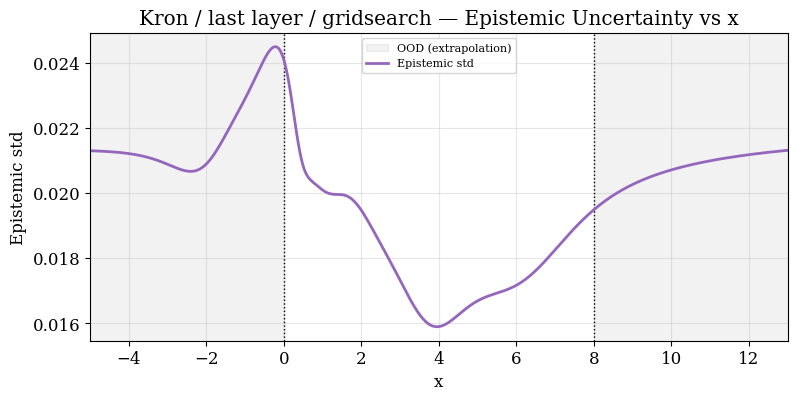

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_ood_epistemic.png


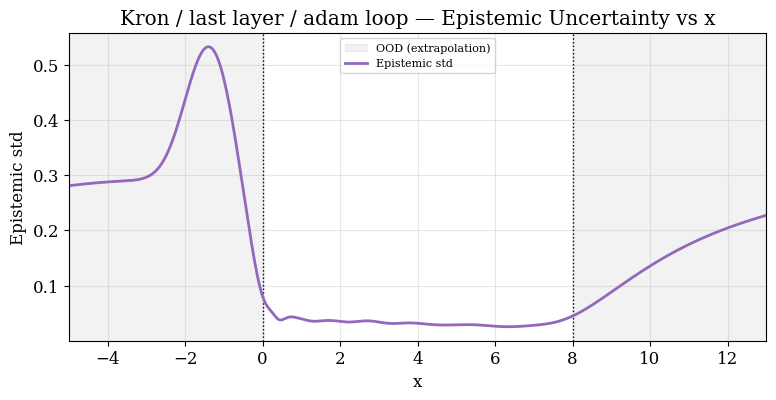

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_ood_epistemic.png


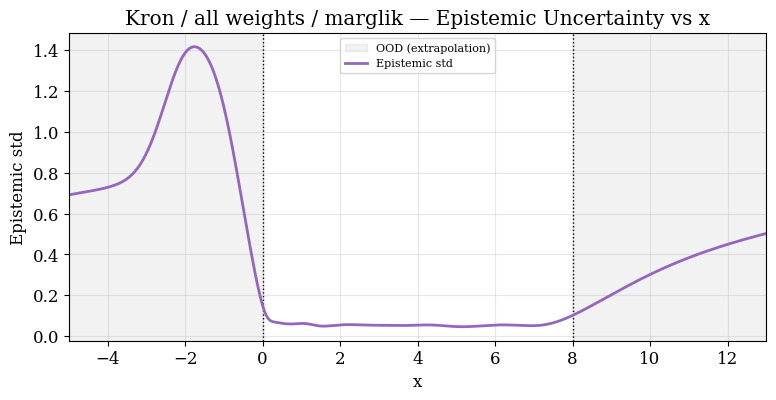

  Saved: sinusoid_comparison_kron_all_marglik_ood_epistemic.png


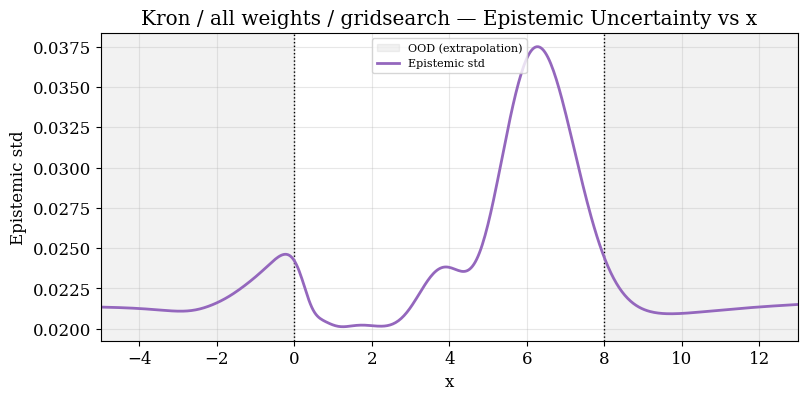

  Saved: sinusoid_comparison_kron_all_gridsearch_ood_epistemic.png


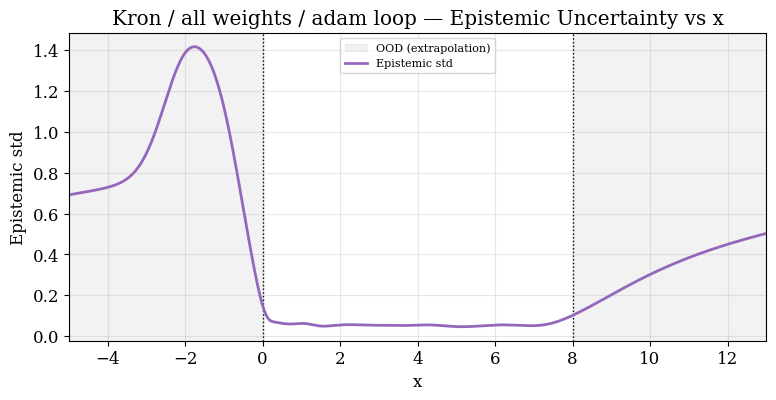

  Saved: sinusoid_comparison_kron_all_adam_loop_ood_epistemic.png


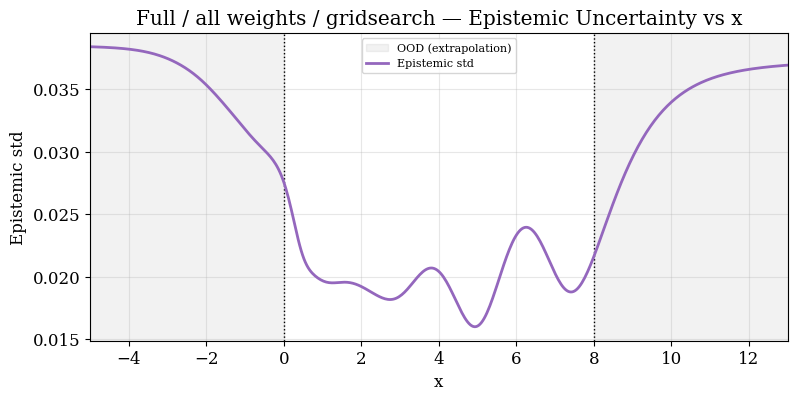

  Saved: sinusoid_comparison_full_all_gridsearch_ood_epistemic.png


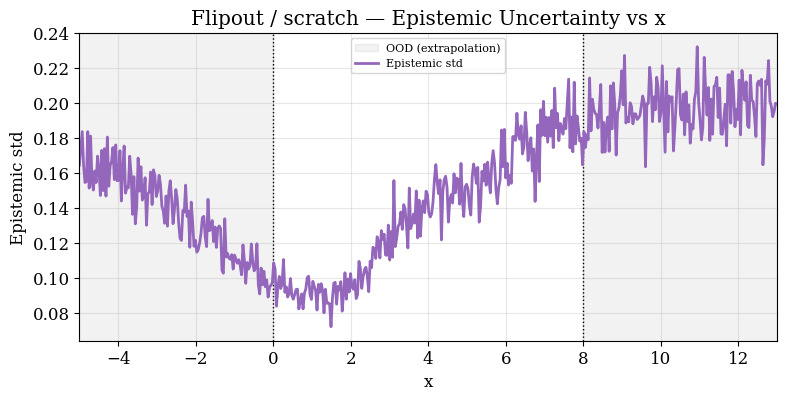

  Saved: sinusoid_comparison_flipout_scratch_ood_epistemic.png


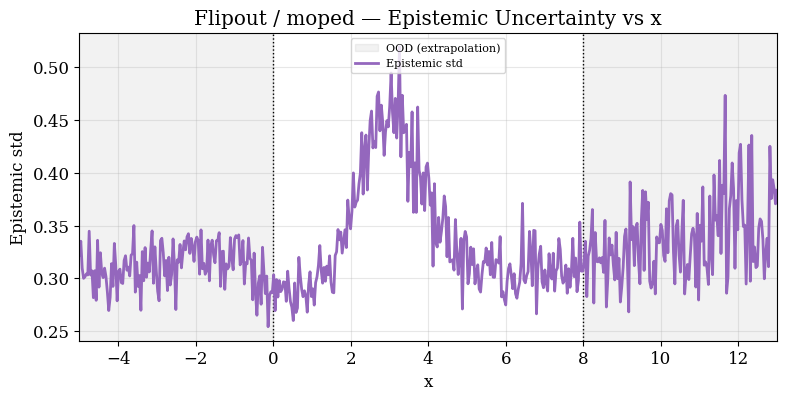

  Saved: sinusoid_comparison_flipout_moped_ood_epistemic.png


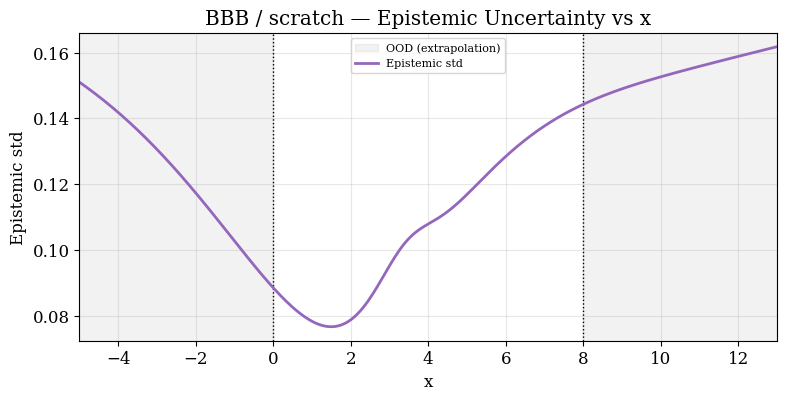

  Saved: sinusoid_comparison_bbb_scratch_ood_epistemic.png


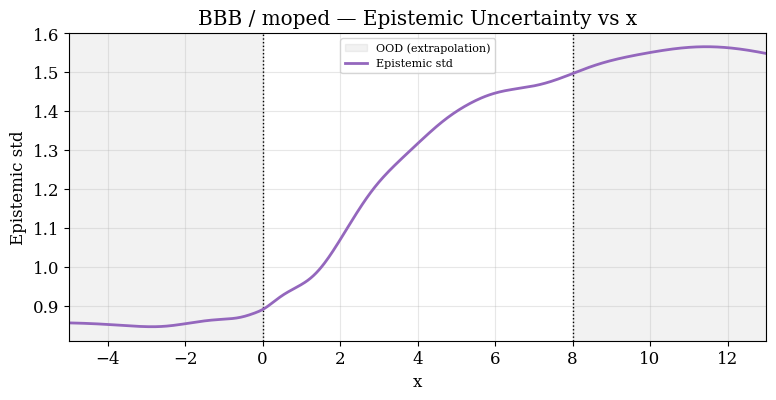

  Saved: sinusoid_comparison_bbb_moped_ood_epistemic.png


In [76]:
# OOD epistemic uncertainty figures
for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    epi = res["epi_std"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi, color="tab:purple", lw=2, label="Epistemic std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} — Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_ood_epistemic.png")

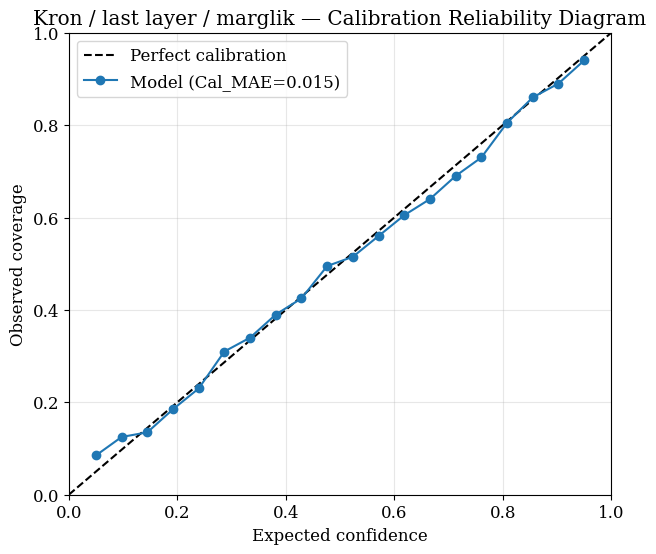

  Saved: sinusoid_comparison_kron_last_layer_marglik_calibration.png


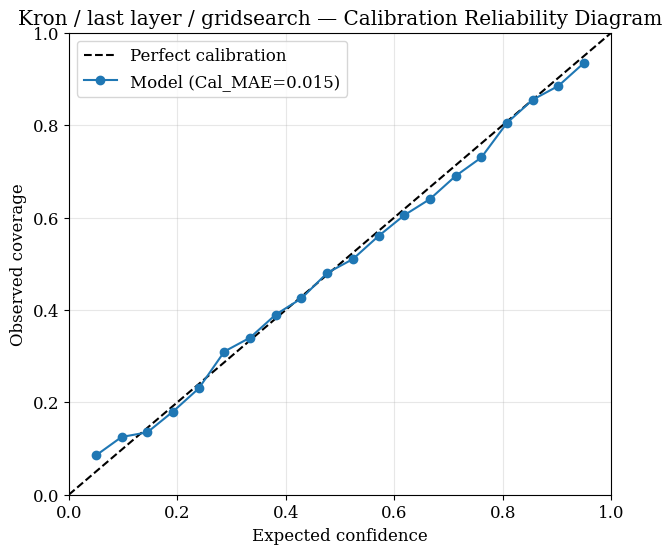

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_calibration.png


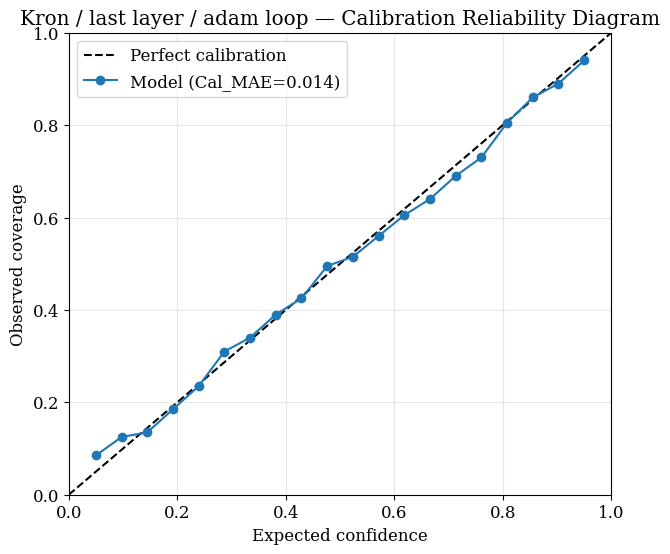

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_calibration.png


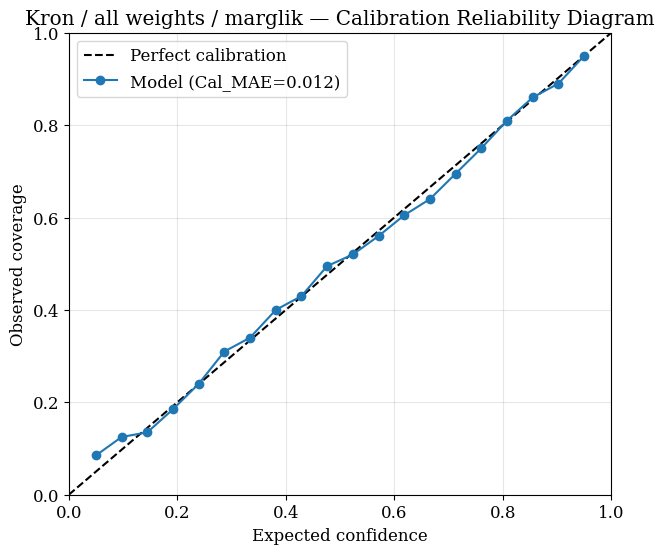

  Saved: sinusoid_comparison_kron_all_marglik_calibration.png


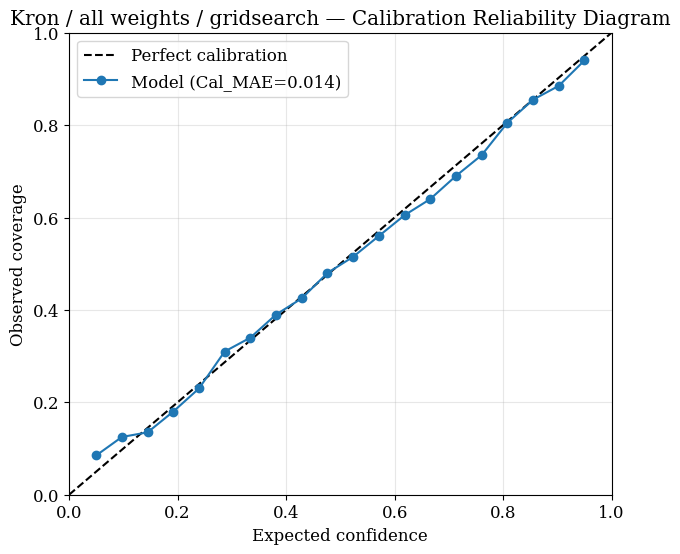

  Saved: sinusoid_comparison_kron_all_gridsearch_calibration.png


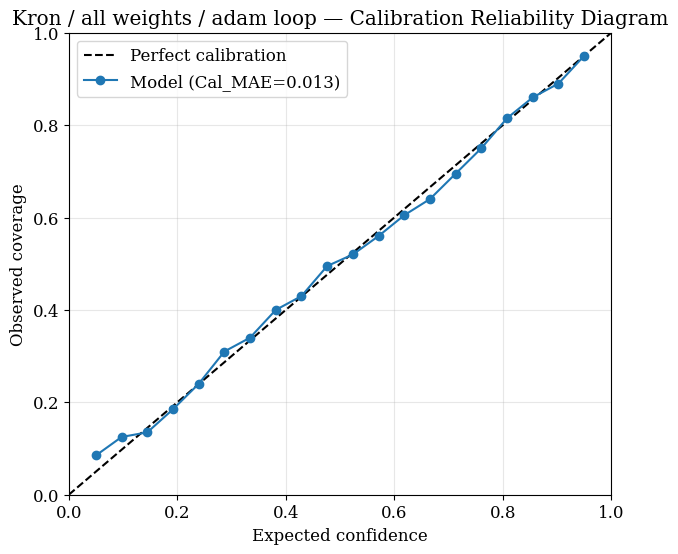

  Saved: sinusoid_comparison_kron_all_adam_loop_calibration.png


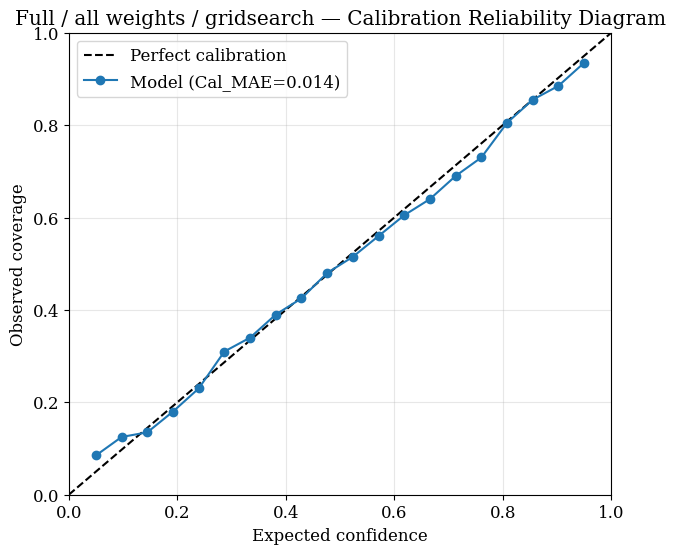

  Saved: sinusoid_comparison_full_all_gridsearch_calibration.png


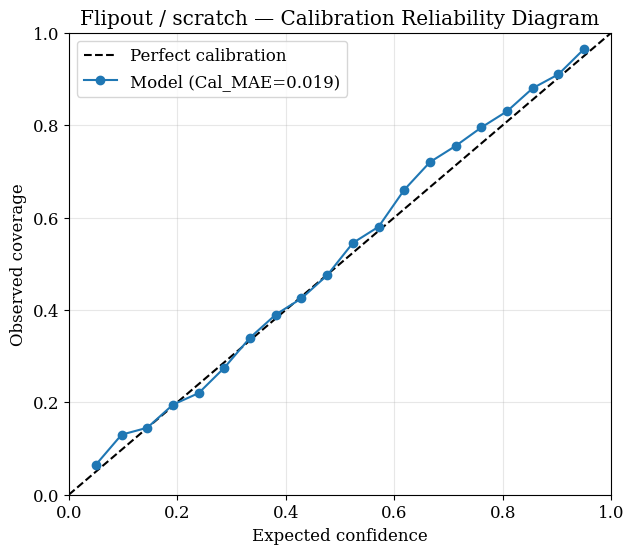

  Saved: sinusoid_comparison_flipout_scratch_calibration.png


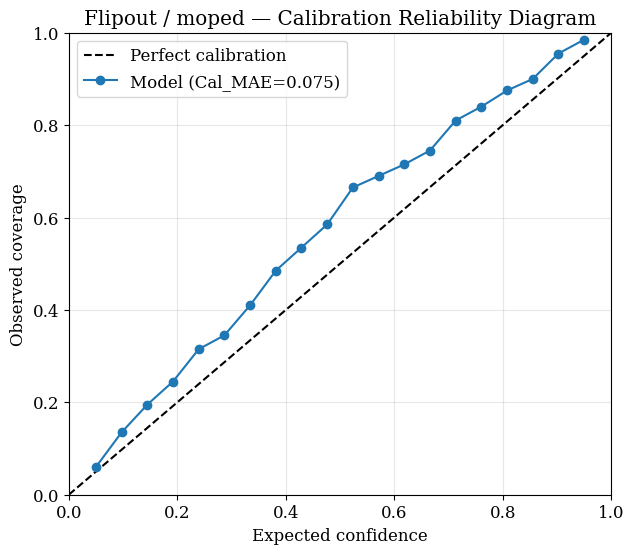

  Saved: sinusoid_comparison_flipout_moped_calibration.png


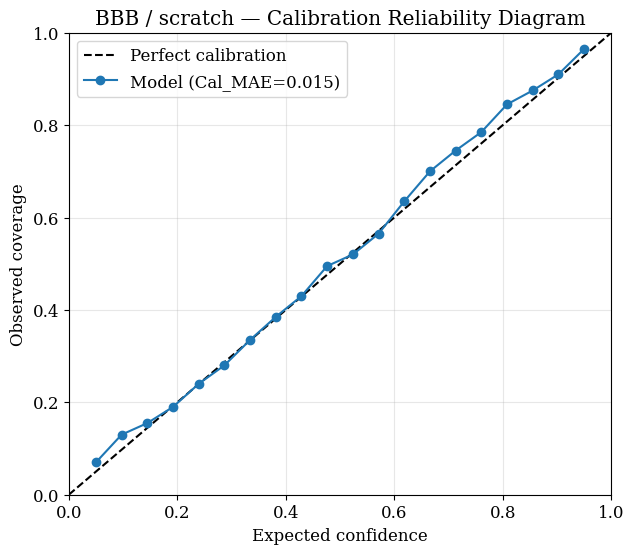

  Saved: sinusoid_comparison_bbb_scratch_calibration.png


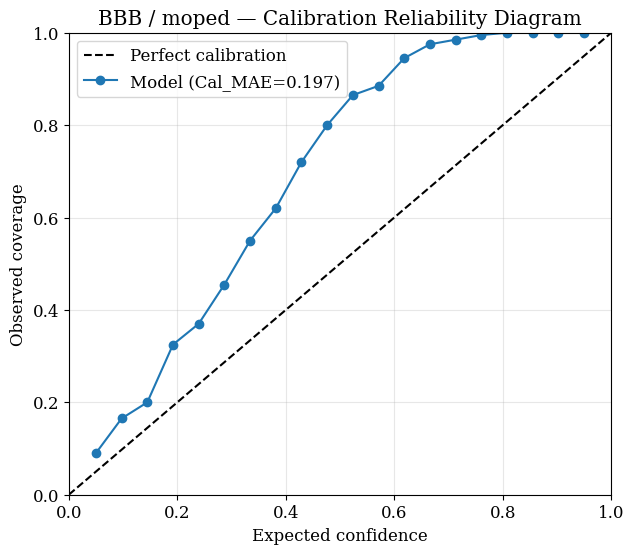

  Saved: sinusoid_comparison_bbb_moped_calibration.png


In [77]:
# Calibration reliability diagrams (ID test set)
conf_levels = np.linspace(0.05, 0.95, 20)

for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    sigma = res.get("sigma", sigma_noise)
    mu_id  = res["mu_id"]
    epi_id = res["epi_id"]
    total_id = np.sqrt(epi_id**2 + sigma**2)
    resid = y_test_id_np - mu_id
    z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, observed, "o-", label=f"Model (Cal_MAE={cal_mae:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} — Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_calibration.png")

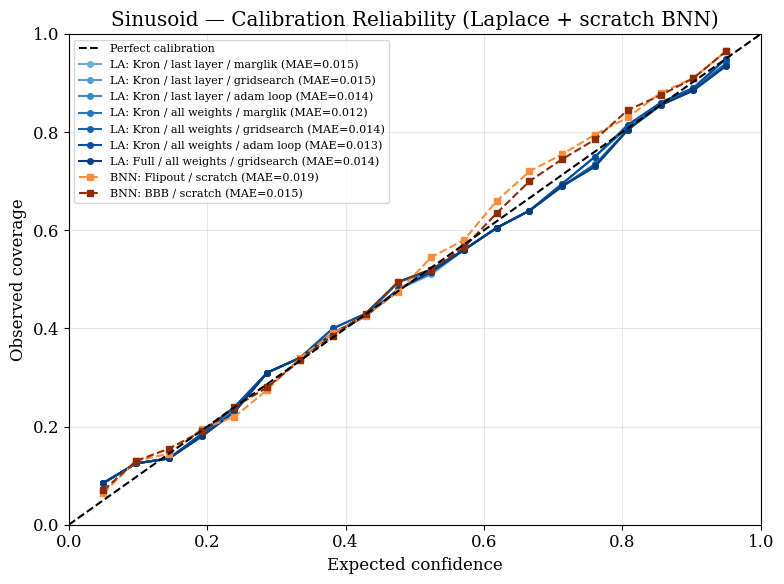

Saved: reliability_sin_all_variants.png


In [78]:
# Combined reliability diagram — all Laplace + scratch BNN variants
POSTER_FIGURES = str(ROOT / "submission" / "CPS_Poster_Template" / "figures")

scratch_bnn_specs = [s for s in bnn_variant_specs if s["variant_name"] in ("flipout_scratch", "bbb_scratch")]

colors_la  = plt.cm.Blues(np.linspace(0.5, 0.95, len(la_variant_specs)))
colors_bnn = plt.cm.Oranges(np.linspace(0.5, 0.95, len(scratch_bnn_specs)))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration", zorder=5)

for spec, color in zip(la_variant_specs, colors_la):
    res = la_results[spec["variant_name"]]
    sigma = res["sigma"]
    total_id = np.sqrt(res["epi_id"]**2 + sigma**2)
    z_abs = np.abs((y_test_id_np - res["mu_id"]) / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))
    ax.plot(conf_levels, observed, "o-", color=color, lw=1.5, ms=4,
            label=f"LA: {spec['plot_title']} (MAE={cal_mae:.3f})")

for spec, color in zip(scratch_bnn_specs, colors_bnn):
    res = bnn_results[spec["variant_name"]]
    total_id = np.sqrt(res["epi_id"]**2 + sigma_noise**2)
    z_abs = np.abs((y_test_id_np - res["mu_id"]) / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))
    ax.plot(conf_levels, observed, "s--", color=color, lw=1.5, ms=4,
            label=f"BNN: {spec['plot_title']} (MAE={cal_mae:.3f})")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
ax.set_title("Sinusoid — Calibration Reliability (Laplace + scratch BNN)")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)
fig.tight_layout()

for out_dir in [FIGURES_DIR, POSTER_FIGURES]:
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(out_dir, "reliability_sin_all_variants.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reliability_sin_all_variants.png")

# MOPED delta sweep: δ ∈ {0.05, 0.1, 0.2}

The original paper (Krishnan et al. 2019) only validated δ ∈ {0.05, 0.1, 0.2} on classification.
Our δ=0.5 (copied from the bayesian-torch README example) is 2.5× above the paper's maximum.
Here we retrain Flipout/MOPED and BBB/MOPED across the paper's range to see if behaviour improves.

In [79]:
DELTA_VALUES = [0.05, 0.1, 0.2]

delta_variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for delta in DELTA_VALUES:
        delta_str = str(delta).replace(".", "")
        delta_variant_specs.append({
            "variant_name": f"{short}_moped_d{delta_str}",
            "model_type": model_type,
            "moped_delta": delta,
            "epochs": 400,
            "plot_title": f"{short.upper() if short == 'bbb' else short.capitalize()} / moped / δ={delta}",
        })

delta_results = {}

for spec in delta_variant_specs:
    vname = spec["variant_name"]
    ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{SEED}.pt")
    net = build_bnn(spec["model_type"], moped=True, moped_delta=spec["moped_delta"])

    if checkpoint_exists(ckpt):
        payload = load_checkpoint(ckpt, map_location="cpu")
        if isinstance(payload, dict) and "model_state_dict" in payload:
            net.load_state_dict(payload["model_state_dict"])
            metrics = dict(payload.get("metrics", {}))
            print(f"  [loaded] {vname}")
    else:
        opt_b = optim.Adam(net.parameters(), lr=1e-3)
        num_samp = len(X_train)
        patience = 75; best_val, best_state, wait, ran = float("inf"), None, 0, 0
        t0 = time.time()
        for epoch in range(spec["epochs"]):
            net.train()
            for xb, yb in train_loader:
                opt_b.zero_grad()
                loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samp
                loss.backward(); opt_b.step()
            ran = epoch + 1
            f_mu_val, _ = bnn_predict(net, X_val, n_samples=20)
            val_mse = float(np.mean((f_mu_val - y_val_np)**2))
            if val_mse < best_val - 1e-5:
                best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
            else:
                wait += 1
                if wait >= patience: break
        if best_state is not None:
            net.load_state_dict(best_state)
        fit_time = time.time() - t0
        metrics = {
            "Model_Type": spec["model_type"], "Init": "MOPED",
            "moped_delta": spec["moped_delta"],
            "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time,
        }
        save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
        print(f"  [trained] {vname} ({fit_time:.1f}s, {ran} epochs)")

    f_mu, epi_std = bnn_predict(net, X_test_grid)
    mu_id, epi_id = bnn_predict(net, X_test_id)
    mu_ood, epi_ood = bnn_predict(net, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma_noise**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma_noise))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    delta_results[vname] = {
        "model": net, "f_mu": f_mu, "epi_std": epi_std,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    print(f"    RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}  "
          f"Cal_MAE={metrics.get('Calibration_MAE', float('nan')):.4f}  "
          f"Epistemic_std={metrics.get('Mean_Epistemic_Std', float('nan')):.4f}  "
          f"Epochs={metrics.get('Epochs','?')}")

  [loaded] flipout_moped_d005
    RMSE=0.3003  NLL=0.2374  Cal_MAE=0.0330  Epistemic_std=0.1379  Epochs=171
  [loaded] flipout_moped_d01


    RMSE=0.3028  NLL=0.2504  Cal_MAE=0.0400  Epistemic_std=0.1668  Epochs=279
  [loaded] flipout_moped_d02
    RMSE=0.3088  NLL=0.2585  Cal_MAE=0.0287  Epistemic_std=0.1609  Epochs=400
  [loaded] bbb_moped_d005
    RMSE=0.3097  NLL=0.2686  Cal_MAE=0.0335  Epistemic_std=0.1638  Epochs=143
  [loaded] bbb_moped_d01
    RMSE=0.3362  NLL=0.3907  Cal_MAE=0.0772  Epistemic_std=0.3065  Epochs=143
  [loaded] bbb_moped_d02
    RMSE=0.4210  NLL=0.6346  Cal_MAE=0.1010  Epistemic_std=0.5031  Epochs=174


In [80]:
# Comparison table: scratch vs MOPED δ=0.5 vs MOPED δ∈{0.05,0.1,0.2}
# Includes ID and OOD metrics + epistemic ratio
ref_variants = [
    ("flipout_scratch", "Flipout / scratch (ref)"),
    ("flipout_moped",   "Flipout / moped / δ=0.5"),
    ("bbb_scratch",     "BBB / scratch (ref)"),
    ("bbb_moped",       "BBB / moped / δ=0.5"),
]

def _make_row(res, sigma):
    m_id  = regression_metrics(y_test_id_np,  res["mu_id"],  np.sqrt(res["epi_id"]**2  + sigma**2))
    m_ood = regression_metrics(y_test_ood_np, res["mu_ood"], np.sqrt(res["epi_ood"]**2 + sigma**2))
    epi_id_mean  = float(res["epi_id"].mean())
    epi_ood_mean = float(res["epi_ood"].mean())
    return {
        "ID RMSE":    m_id["RMSE"],
        "ID NLL":     m_id["NLL"],
        "ID Cal MAE": res["metrics"].get("Calibration_MAE", float("nan")),
        "ID Epi":     epi_id_mean,
        "OOD RMSE":   m_ood["RMSE"],
        "OOD NLL":    m_ood["NLL"],
        "OOD Epi":    epi_ood_mean,
        "Epi Ratio":  epi_ood_mean / (epi_id_mean + 1e-12),
        "Epochs":     res["metrics"].get("Epochs", float("nan")),
    }

rows, labels = [], []

for vname, label in ref_variants:
    rows.append(_make_row(bnn_results[vname], sigma_noise))
    labels.append(label)

for spec in delta_variant_specs:
    rows.append(_make_row(delta_results[spec["variant_name"]], sigma_noise))
    labels.append(spec["plot_title"])

cmp_df = pd.DataFrame(rows, index=labels)
cmp_df.index.name = "Variant"
float_cols = ["ID RMSE", "ID NLL", "ID Cal MAE", "ID Epi",
              "OOD RMSE", "OOD NLL", "OOD Epi", "Epi Ratio"]
for c in float_cols:
    cmp_df[c] = cmp_df[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
cmp_df["Epochs"] = cmp_df["Epochs"].map(lambda x: int(x) if pd.notna(x) else "-")

print("MOPED delta sweep — ID vs OOD (Epi Ratio = OOD epistemic / ID epistemic)")
display(cmp_df)

cmp_df.to_csv("results/metrics/sinusoid_delta_sweep_metrics.csv")
print("Saved to results/metrics/sinusoid_delta_sweep_metrics.csv")

MOPED delta sweep — ID vs OOD (Epi Ratio = OOD epistemic / ID epistemic)


,ID RMSE,ID NLL,ID Cal MAE,ID Epi,OOD RMSE,OOD NLL,OOD Epi,Epi Ratio,Epochs
Variant,,,,,,,,,
Flipout / scratch (ref),0.3101,0.2580,0.0187,0.1373,2.6562,28.1407,0.1662,1.2106,479
Flipout / moped / δ=0.5,0.3500,0.4182,0.0745,0.3159,2.7473,19.3282,0.3233,1.0232,400
BBB / scratch (ref),0.3083,0.2505,0.0146,0.1247,2.5489,28.9939,0.1328,1.0654,1000
BBB / moped / δ=0.5,0.6277,1.2282,0.1973,1.1772,0.9951,1.4964,1.1282,0.9584,135
Flipout / moped / δ=0.05,0.3003,0.2374,0.0330,0.1379,1.5628,12.5674,0.0775,0.5619,171
Flipout / moped / δ=0.1,0.3028,0.2504,0.0400,0.1668,1.8195,16.1404,0.1106,0.6630,279
Flipout / moped / δ=0.2,0.3088,0.2585,0.0287,0.1609,2.5124,29.4321,0.1322,0.8217,400
BBB / moped / δ=0.05,0.3097,0.2686,0.0335,0.1638,1.5576,12.3708,0.0834,0.5093,143
BBB / moped / δ=0.1,0.3362,0.3907,0.0772,0.3065,1.5212,9.9243,0.1672,0.5453,143


Saved to results/metrics/sinusoid_delta_sweep_metrics.csv


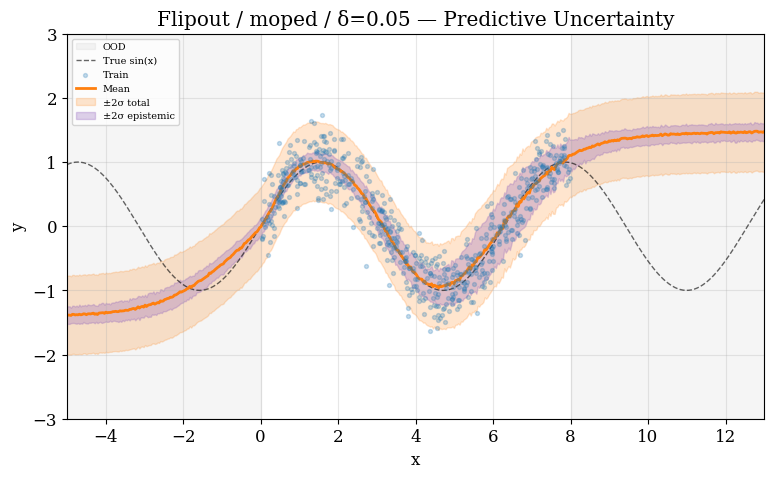

  Saved: sinusoid_comparison_flipout_moped_d005_prediction.png


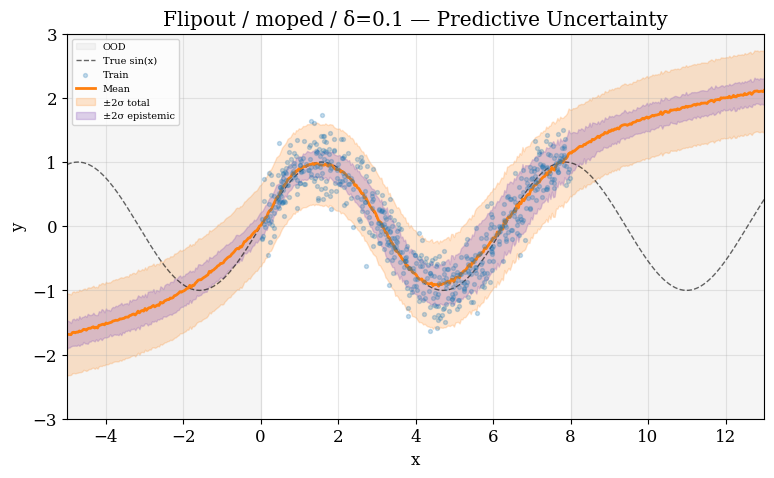

  Saved: sinusoid_comparison_flipout_moped_d01_prediction.png


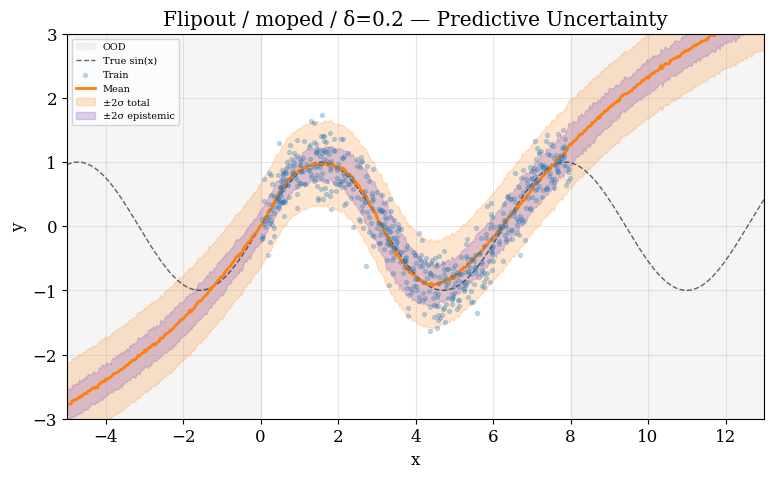

  Saved: sinusoid_comparison_flipout_moped_d02_prediction.png


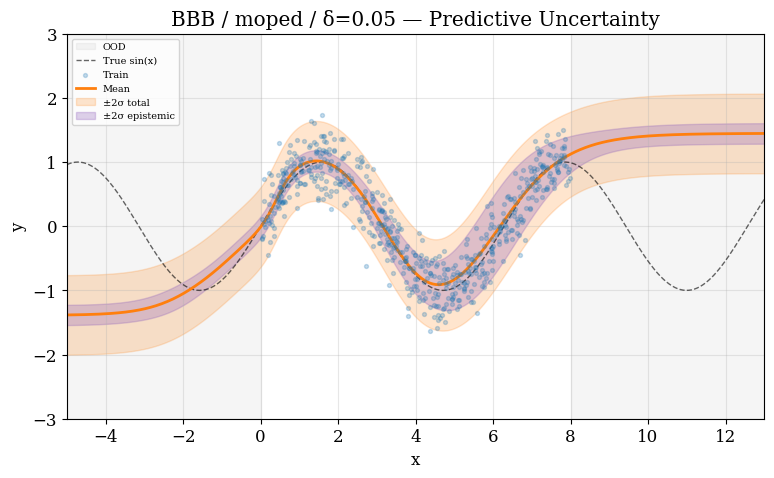

  Saved: sinusoid_comparison_bbb_moped_d005_prediction.png


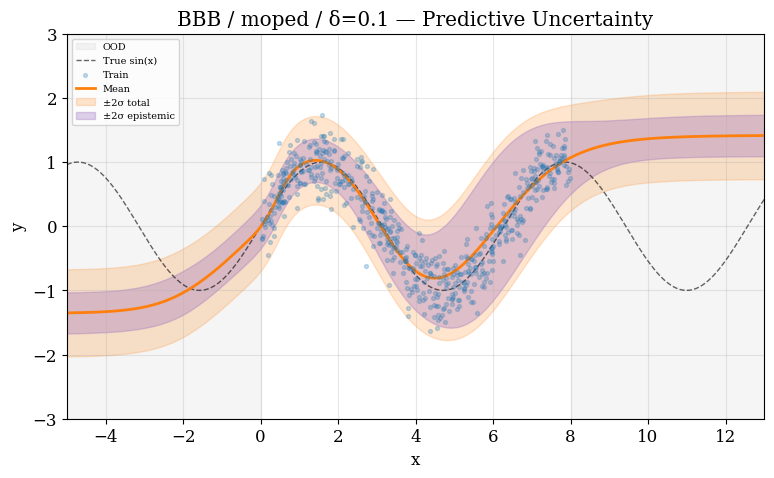

  Saved: sinusoid_comparison_bbb_moped_d01_prediction.png


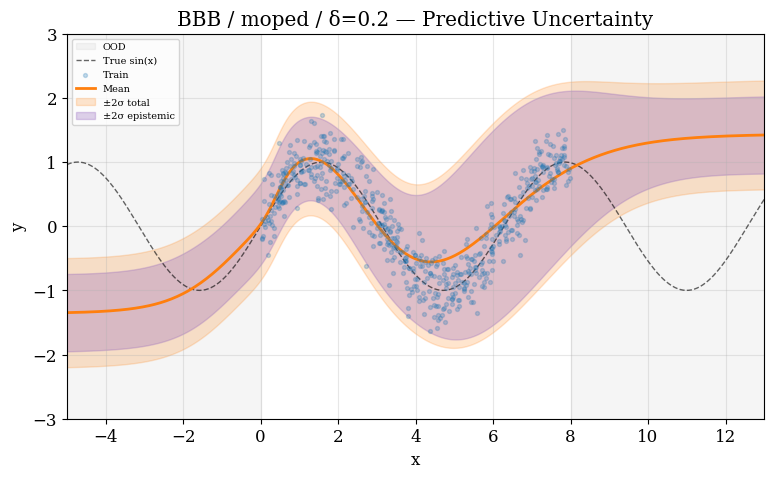

  Saved: sinusoid_comparison_bbb_moped_d02_prediction.png


In [81]:
# Prediction plots for each delta variant
for spec in delta_variant_specs:
    vname = spec["variant_name"]
    res = delta_results[vname]
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma_noise,
                    f"{spec['plot_title']} — Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_prediction.png")

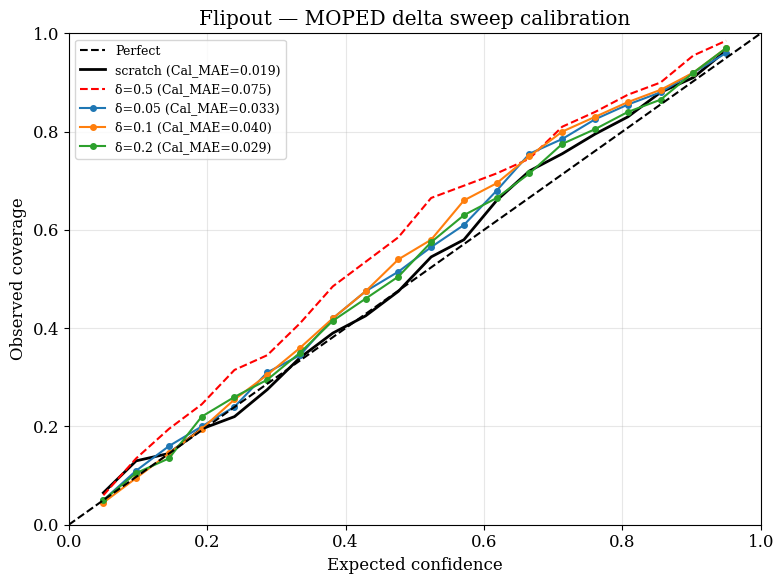

Saved: sinusoid_flipout_moped_delta_calibration.png


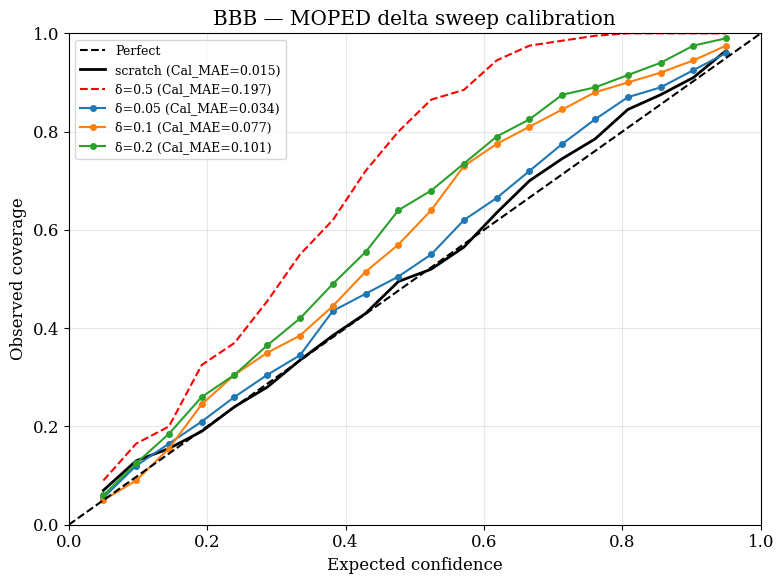

Saved: sinusoid_bbb_moped_delta_calibration.png


In [82]:
# Combined calibration plot: scratch + all MOPED deltas (Flipout and BBB separately)
conf_levels = np.linspace(0.05, 0.95, 20)

for model_short, model_type in [("flipout", "Flipout"), ("bbb", "BBB")]:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect", zorder=5)

    # scratch baseline
    scratch_res = bnn_results[f"{model_short}_scratch"]
    total_id = np.sqrt(scratch_res["epi_id"]**2 + sigma_noise**2)
    z = np.abs((y_test_id_np - scratch_res["mu_id"]) / np.clip(total_id, 1e-12, None))
    obs = np.array([float(np.mean(z <= _norm.ppf((1+c)/2))) for c in conf_levels])
    ax.plot(conf_levels, obs, "k-", lw=2, label=f"scratch (Cal_MAE={float(np.mean(np.abs(obs-conf_levels))):.3f})")

    # δ=0.5 baseline
    moped_res = bnn_results[f"{model_short}_moped"]
    total_id = np.sqrt(moped_res["epi_id"]**2 + sigma_noise**2)
    z = np.abs((y_test_id_np - moped_res["mu_id"]) / np.clip(total_id, 1e-12, None))
    obs = np.array([float(np.mean(z <= _norm.ppf((1+c)/2))) for c in conf_levels])
    ax.plot(conf_levels, obs, "r--", lw=1.5, label=f"δ=0.5 (Cal_MAE={float(np.mean(np.abs(obs-conf_levels))):.3f})")

    # delta sweep
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for spec, color in zip([s for s in delta_variant_specs if model_short in s["variant_name"]], colors):
        res = delta_results[spec["variant_name"]]
        total_id = np.sqrt(res["epi_id"]**2 + sigma_noise**2)
        z = np.abs((y_test_id_np - res["mu_id"]) / np.clip(total_id, 1e-12, None))
        obs = np.array([float(np.mean(z <= _norm.ppf((1+c)/2))) for c in conf_levels])
        delta = spec["moped_delta"]
        ax.plot(conf_levels, obs, "o-", color=color, lw=1.5, ms=4,
                label=f"δ={delta} (Cal_MAE={float(np.mean(np.abs(obs-conf_levels))):.3f})")

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{model_type} — MOPED delta sweep calibration")
    ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{model_short}_moped_delta_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: sinusoid_{model_short}_moped_delta_calibration.png")